In [34]:
import numpy as np
import math

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Operator, Statevector

np.set_printoptions(precision=6, suppress=True)

# Problem Hamiltonian
# H = 0.7 XX - 0.5 ZY + 0.8 YZ

terms = [
    ( 0.7, "XX"),
    (-0.5, "ZY"),
    ( 0.8, "YZ"),
]

n_system_qubits = 2
L = len(terms)

alpha = sum(abs(c) for c, _ in terms)

n_index_qubits = 2          # because 3 terms need |00>, |01>, |10>
index_dim = 2 ** n_index_qubits

print("Hamiltonian terms:", terms)
print("Number of system qubits:", n_system_qubits)
print("Number of Pauli terms:", L)
print("alpha =", alpha)
print("Index qubits:", n_index_qubits)
print("Index dimension:", index_dim)

Hamiltonian terms: [(0.7, 'XX'), (-0.5, 'ZY'), (0.8, 'YZ')]
Number of system qubits: 2
Number of Pauli terms: 3
alpha = 2.0
Index qubits: 2
Index dimension: 4


In [35]:
# Matrix helpers for verification only

def pauli_string_operator_qiskit(pauli_string):
    """
    Builds the matrix for a Pauli string using Qiskit's qubit ordering.
    pauli_string[0] acts on system qubit 0.
    pauli_string[1] acts on system qubit 1.
    """
    qc = QuantumCircuit(n_system_qubits)

    for q, p in enumerate(pauli_string):
        if p == "I":
            pass
        elif p == "X":
            qc.x(q)
        elif p == "Y":
            qc.y(q)
        elif p == "Z":
            qc.z(q)
        else:
            raise ValueError(f"Unknown Pauli: {p}")

    return Operator(qc).data


def build_hamiltonian_matrix(terms):
    dim = 2 ** n_system_qubits
    H = np.zeros((dim, dim), dtype=complex)

    for coeff, pauli_string in terms:
        H += coeff * pauli_string_operator_qiskit(pauli_string)

    return H


H_mat = build_hamiltonian_matrix(terms)
H_norm_mat = H_mat / alpha

evals, evecs = np.linalg.eigh(H_mat)

print("H matrix:")
print(H_mat)

print("\nEigenvalues of H:")
print(evals)

#print("\nGround-state energy:")
#print(evals[0])

H matrix:
[[0. +0.j  0. -0.8j 0. +0.5j 0.7+0.j ]
 [0. +0.8j 0. +0.j  0.7+0.j  0. -0.5j]
 [0. -0.5j 0.7+0.j  0. +0.j  0. +0.8j]
 [0.7+0.j  0. +0.5j 0. -0.8j 0. +0.j ]]

Eigenvalues of H:
[-2.   0.4  0.6  1. ]


For the matrix-representation verification block, converted each Pauli string into its corresponding matrix, take the tensor product across the two qubits, multiply by its coefficient, and sum the terms to obtain the full 4x4 Hamiltonian matrix. This is only a classical verification step, not part of the quantum oracle itself, to check properties such as Hermition and the exact eigenvalues, which gives a reference against which the later circuit-based construction can be validated.

|G> vector:
[0.591608+0.j 0.5     +0.j 0.632456+0.j 0.      +0.j]
Norm of |G> = 1.0


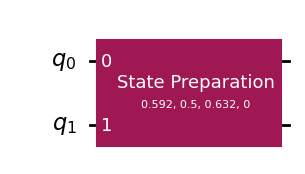

In [36]:
# Build coefficient state |G>

G_vec = np.zeros(index_dim, dtype=complex)

for j, (coeff, pauli_string) in enumerate(terms):
    G_vec[j] = np.sqrt(abs(coeff) / alpha)

print("|G> vector:")
print(G_vec)
print("Norm of |G> =", np.linalg.norm(G_vec))

PREPARE_G = StatePreparation(G_vec)
PREPARE_G.name = "PREPARE_G"

PREPARE_G_DAGGER = PREPARE_G.inverse()
PREPARE_G_DAGGER.name = "PREPARE_G†"

prep_test = QuantumCircuit(n_index_qubits)
prep_test.append(PREPARE_G, range(n_index_qubits))

prep_test.draw("mpl")

$$
\alpha=\sum_{j=0}^{L-1}|c_j|
$$

$$
|G\rangle
=
\sum_{j=0}^{L-1}
\sqrt{\frac{|c_j|}{\alpha}}
\,|j\rangle
$$

In [ ]:

# Problem-specific SELECT helpers

def control_on_index(qc, idx, bitstring):
    """ Convert control-on-specific-index state into control-on-|11>.
    bitstring is written in the same order as idx:
    bitstring[0] controls idx[0],
    bitstring[1] controls idx[1]."""
    for q, b in zip(idx, bitstring):
        if b == "0":
            qc.x(q)

def undo_control_on_index(qc, idx, bitstring):
    """ Undo control_on_index."""
    for q, b in zip(idx, bitstring):
        if b == "0":
            qc.x(q)

def controlled_X_with_index(qc, idx, target):
    """Apply X on target controlled by idx == |11>."""
    qc.mcx([idx[0], idx[1]], target)

def controlled_Z_with_index(qc, idx, target):
    """ Apply Z on target controlled by idx == |11>.
    Implemented as H - controlled X - H."""
    qc.h(target)
    qc.mcx([idx[0], idx[1]], target)
    qc.h(target)

def controlled_Y_with_index(qc, idx, target):
    """ Apply Y on target controlled by idx == |11>.
    Y = S X S† in operator order.
    Circuit order: S†, X, S."""
    qc.sdg(target)
    qc.mcx([idx[0], idx[1]], target)
    qc.s(target)

def controlled_minus_for_index(qc, idx):
    """ Apply -1 phase when idx == |11>.
    This is used for the negative coefficient term."""
    qc.h(idx[1])
    qc.cx(idx[0], idx[1])
    qc.h(idx[1])

These helper functions apply a Pauli operation only when the index register represents a particular Hamiltonian term. Firstly used X gates to temporarily map the required index state to |11>, because the multi-controlled gates activate on all-one controls. Then applied controlled X, Y, or Z operations to the system qubits and undo the temporary mapping. The separate phase helper applies a -1 factor for terms with negative coefficients, such as -0.5 ZY

SELECT built.
SELECT qubits = 4
SELECT depth = 14
SELECT gate count = OrderedDict([('x', 8), ('ccx', 6), ('h', 6), ('sdg', 2), ('s', 2), ('cx', 1)])


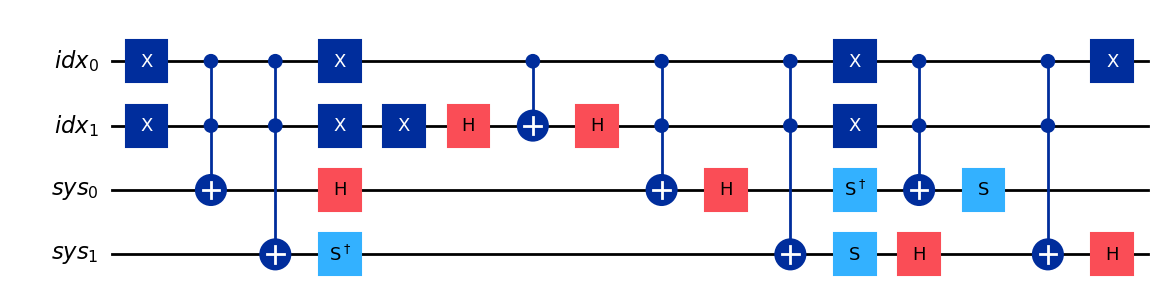

In [ ]:
# Build problem-specific SELECT
# IMPORTANT Qiskit little-endian mapping:
# G_vec[0] -> idx value 0 -> idx[0]=0, idx[1]=0 -> bitstring "00"
# G_vec[1] -> idx value 1 -> idx[0]=1, idx[1]=0 -> bitstring "10"
# G_vec[2] -> idx value 2 -> idx[0]=0, idx[1]=1 -> bitstring "01"

# encoded state 0: "00" -> +XX
# encoded state 1: "10" -> -ZY
# encoded state 2: "01" -> +YZ
# encoded state 3: "11" -> unused / identity


idx = QuantumRegister(n_index_qubits, "idx")
sys = QuantumRegister(n_system_qubits, "sys")
SELECT_qc = QuantumCircuit(idx, sys, name="SELECT")

# Term 0: encoded state 0 -> bitstring "00" -> +XX
control_on_index(SELECT_qc, idx, "00")
controlled_X_with_index(SELECT_qc, idx, sys[0])
controlled_X_with_index(SELECT_qc, idx, sys[1])
undo_control_on_index(SELECT_qc, idx, "00")

# Term 1: encoded state 1 -> bitstring "10" -> -ZY
control_on_index(SELECT_qc, idx, "10")
# negative coefficient sign
controlled_minus_for_index(SELECT_qc, idx)
# Z on system qubit 0
controlled_Z_with_index(SELECT_qc, idx, sys[0])
# Y on system qubit 1
controlled_Y_with_index(SELECT_qc, idx, sys[1])
undo_control_on_index(SELECT_qc, idx, "10")

# Term 2: encoded state 2 -> bitstring "01" -> +YZ
control_on_index(SELECT_qc, idx, "01")
# Y on system qubit 0
controlled_Y_with_index(SELECT_qc, idx, sys[0])
# Z on system qubit 1
controlled_Z_with_index(SELECT_qc, idx, sys[1])
undo_control_on_index(SELECT_qc, idx, "01")

SELECT_gate = SELECT_qc.to_gate()
SELECT_gate.name = "SELECT"

print("SELECT built.")
print("SELECT qubits =", SELECT_qc.num_qubits)
print("SELECT depth =", SELECT_qc.depth())
print("SELECT gate count =", SELECT_qc.count_ops())

SELECT_qc.draw("mpl")

Here I construct the full SELECT unitary by mapping each index-register basis state to its corresponding Pauli string. Because Qiskit is little-endian, the encoded states are 00 for XX, 10 for -ZY, and 01 for YZ. For each term, I activate the required index condition, apply the controlled Pauli operations and coefficient sign, then uncompute the temporary index mapping. The unused state 11 acts as identity.

$$
\mathrm{SELECT}
=
\sum_{j=0}^{L-1}
|j\rangle\langle j|
\otimes
\operatorname{sgn}(c_j)P_j
$$

For this Hamiltonian:

$$
\mathrm{SELECT}
=
|0\rangle\langle 0|\otimes XX
-
|1\rangle\langle 1|\otimes ZY
+
|2\rangle\langle 2|\otimes YZ
+
|3\rangle\langle 3|\otimes I
$$

In [39]:
# Verification 1: SELECT block encoding

SELECT_mat = Operator(SELECT_qc).data

dim_idx = 2 ** n_index_qubits
dim_sys = 2 ** n_system_qubits

block = np.zeros((dim_sys, dim_sys), dtype=complex)

# Qiskit ordering:
# index register qubits come first, so index bits are lower-order bits.
# Full basis index = idx_value + dim_idx * sys_value

for sys_row in range(dim_sys):
    for sys_col in range(dim_sys):
        val = 0.0 + 0.0j

        for idx_row in range(dim_idx):
            for idx_col in range(dim_idx):
                full_row = idx_row + dim_idx * sys_row
                full_col = idx_col + dim_idx * sys_col

                val += (
                    np.conj(G_vec[idx_row])
                    * G_vec[idx_col]
                    * SELECT_mat[full_row, full_col]
                )

        block[sys_row, sys_col] = val

err = np.linalg.norm(block - H_norm_mat)

print("Verification 1: SELECT block encoding")
print("|| <G|SELECT|G> - H/alpha || =", err)

print("\nExtracted block <G|SELECT|G>:")
print(block)

print("\nExpected H/alpha:")
print(H_norm_mat)

Verification 1: SELECT block encoding
|| <G|SELECT|G> - H/alpha || = 5.20740757162067e-16

Extracted block <G|SELECT|G>:
[[0.  +0.j   0.  -0.4j  0.  +0.25j 0.35+0.j  ]
 [0.  +0.4j  0.  +0.j   0.35+0.j   0.  -0.25j]
 [0.  -0.25j 0.35+0.j   0.  +0.j   0.  +0.4j ]
 [0.35+0.j   0.  +0.25j 0.  -0.4j  0.  +0.j  ]]

Expected H/alpha:
[[0.  +0.j   0.  -0.4j  0.  +0.25j 0.35+0.j  ]
 [0.  +0.4j  0.  +0.j   0.35+0.j   0.  -0.25j]
 [0.  -0.25j 0.35+0.j   0.  +0.j   0.  +0.4j ]
 [0.35+0.j   0.  +0.25j 0.  -0.4j  0.  +0.j  ]]


Converted the SELECT circuit into its full unitary matrix and projected the index register onto the prepared coefficient state |G>. This extracts the effective system block
$$ \langle G|\mathrm{SELECT}|G\rangle.$$
Then compared that block with the classically computed H/alpha. The error was approximately 5.2 x 10^-16, so the circuit implements the intended block encoding up to numerical precision.

In [40]:
# # Build fixed trial state |psi>


# def build_trial_state_circuit():
#     qc = QuantumCircuit(n_system_qubits, name="PREPARE_psi")

#     qc.ry(0.37, 0)
#     qc.rz(-0.82, 0)

#     qc.ry(0.58, 1)
#     qc.rz(-0.51, 1)

#     qc.cx(0, 1)

#     return qc


# PREPARE_psi_qc = build_trial_state_circuit()
# PREPARE_psi_gate = PREPARE_psi_qc.to_gate()
# PREPARE_psi_gate.name = "PREPARE_psi"

# psi_state = Statevector.from_instruction(PREPARE_psi_qc).data

# E_norm_theory = np.real(np.vdot(psi_state, H_norm_mat @ psi_state))
# E_theory = alpha * E_norm_theory

# p_theory = 0.5 - 0.5 * E_norm_theory

# print("E_norm = <psi|H/alpha|psi> =", E_norm_theory)
# print("E = <psi|H|psi> =", E_theory)
# print("p_theory = 1/2 - 1/2 E_norm =", p_theory)

# PREPARE_psi_qc.draw("mpl")

In [41]:
# # Build probability oracle U_p

# anc = QuantumRegister(1, "anc")
# idx = QuantumRegister(n_index_qubits, "idx")
# sys = QuantumRegister(n_system_qubits, "sys")

# U_p_qc = QuantumCircuit(anc, idx, sys, name="U_p")

# # Hadamard-test ancilla
# U_p_qc.h(anc[0])

# # Prepare |G>
# U_p_qc.append(PREPARE_G, idx[:])

# # Prepare |psi>
# #U_p_qc.append(PREPARE_psi_gate, sys[:])

# # Controlled SELECT by ancilla
# # Make SELECT controlled by the ancilla:
# # c_SELECT = |0><0| ⊗ I + |1><1| ⊗ SELECT
# controlled_SELECT = SELECT_gate.control(1)
# controlled_SELECT.name = "c_SELECT"
# # Apply c_SELECT on [ancilla] + [index] + [system]
# # Since <G|SELECT|G> = H/alpha, the final ancilla probability encodes:
# # p = 1/2 - 1/2 <psi|H/alpha|psi>
# U_p_qc.append(controlled_SELECT, [anc[0]] + idx[:] + sys[:])

# # Final Hadamard
# U_p_qc.h(anc[0])

# U_p_gate = U_p_qc.to_gate()
# U_p_gate.name = "U_p"

# U_p_dagger_gate = U_p_gate.inverse()
# U_p_dagger_gate.name = "U_p†"

# print("U_p built.")
# print("U_p qubits =", U_p_qc.num_qubits)
# print("U_p depth =", U_p_qc.depth())
# print("U_p gate count =", U_p_qc.count_ops())

# U_p_qc.draw("mpl")

In [42]:
anc = QuantumRegister(1, "anc")
idx = QuantumRegister(n_index_qubits, "idx")
sys = QuantumRegister(n_system_qubits, "sys")

U_p_qc = QuantumCircuit(anc, idx, sys, name="U_p")

# Hadamard-test ancilla
U_p_qc.h(anc[0])

# Prepare Hamiltonian coefficient state |G>
U_p_qc.append(PREPARE_G, idx[:])

# Apply SELECT only on the ancilla-|1> branch
controlled_SELECT = SELECT_gate.control(1)
controlled_SELECT.name = "c_SELECT"

U_p_qc.append(
    controlled_SELECT,
    [anc[0]] + idx[:] + sys[:]
)

# Uncompute the coefficient state
U_p_qc.append(PREPARE_G.inverse(), idx[:])

# Interfere the two ancilla branches
U_p_qc.h(anc[0])

U_p_gate = U_p_qc.to_gate()
U_p_gate.name = "U_p"

U_p_dagger_gate = U_p_gate.inverse()
U_p_dagger_gate.name = "U_p†"

The probability oracle formation as in Secrtion 7.1 from the paper.

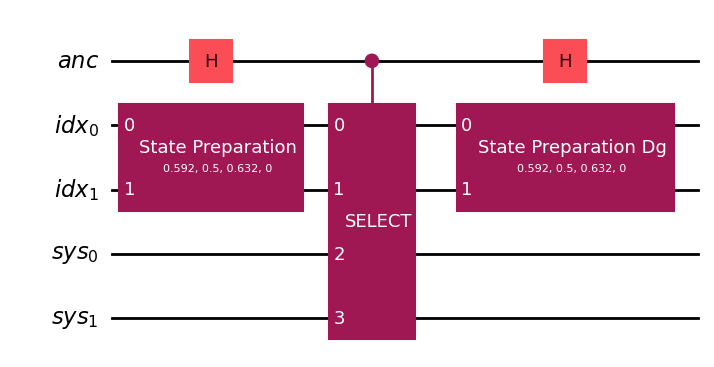

In [43]:
U_p_qc.draw("mpl")

In [44]:
# # Verification 2: Probability oracle

# sv = Statevector.from_instruction(U_p_qc).data

# prob_anc_1 = 0.0

# # ancilla is qubit 0, since anc register is first
# for basis_index, amp in enumerate(sv):
#     anc_bit = (basis_index >> 0) & 1

#     if anc_bit == 1:
#         prob_anc_1 += abs(amp) ** 2

# print("Verification 2: Probability oracle")
# print("p_circuit =", prob_anc_1)
# print("p_theory  =", p_theory)
# print("absolute error =", abs(prob_anc_1 - p_theory))

In [47]:
# Build reflections

n_work_qubits = 1 + n_index_qubits + n_system_qubits

print("n_work_qubits =", n_work_qubits)

def build_R_good_gate(n_work_qubits, ancilla_position=0):
    """
    R_good = I - 2 Pi_good.
    Good state is ancilla = 1.
    So this applies -1 phase when ancilla is |1>.
    """
    qc = QuantumCircuit(n_work_qubits, name="R_good")

    qc.z(ancilla_position)

    return qc.to_gate()


def build_R_zero_gate(
    n_index_qubits,
    n_system_qubits,
    ancilla_position=0,
):
    """
    Phase-flips states for which:
        ancilla = 0
        index register = |0...0>
    while leaving the system register unrestricted.
    """
    n_work_qubits = 1 + n_index_qubits + n_system_qubits
    qc = QuantumCircuit(n_work_qubits, name="R_zero")

    anc_qubit = ancilla_position
    idx_qubits = list(range(1, 1 + n_index_qubits))
    controls = [anc_qubit] + idx_qubits

    # Map anc=0 and idx=0...0 to all-one controls
    qc.x(controls)

    if len(controls) == 1:
        qc.z(controls[0])
    else:
        target = controls[-1]
        remaining_controls = controls[:-1]

        qc.h(target)
        qc.mcx(remaining_controls, target)
        qc.h(target)

    qc.x(controls)

    return qc.to_gate()


R_good_gate = build_R_good_gate(n_work_qubits, ancilla_position=0)
R_zero_gate = build_R_zero_gate(n_index_qubits, n_system_qubits)

print("R_good and R_zero built.")

n_work_qubits = 5
R_good and R_zero built.


G_U built.
G_U qubits = 5
G_U depth = 4
G_U gate count = OrderedDict([('U_p', 1), ('R_good', 1), ('U_p†', 1), ('R_zero', 1)])


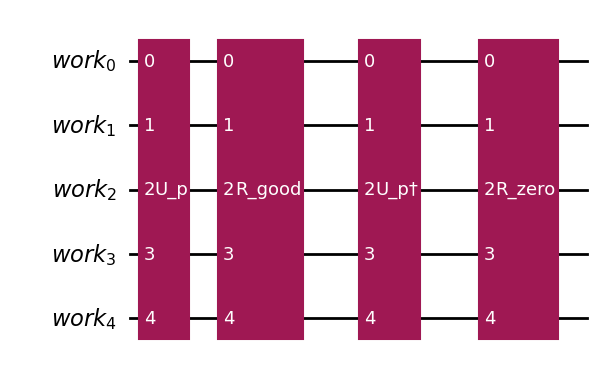

In [48]:
# Build Grover/reflection operator G_U

work = QuantumRegister(n_work_qubits, "work")

G_U_qc = QuantumCircuit(work, name="G_U")

G_U_qc.append(U_p_gate, work[:])
G_U_qc.append(R_good_gate, work[:])
G_U_qc.append(U_p_dagger_gate, work[:])
G_U_qc.append(R_zero_gate, work[:])

G_U_gate = G_U_qc.to_gate()
G_U_gate.name = "G_U"

G_U_dagger_gate = G_U_gate.inverse()
G_U_dagger_gate.name = "G_U†"

print("G_U built.")
print("G_U qubits =", G_U_qc.num_qubits)
print("G_U depth =", G_U_qc.depth())
print("G_U gate count =", G_U_qc.count_ops())

G_U_qc.draw("mpl")

The probability oracle separates the state into good and bad subspaces. The good-state reflection flips the phase of the branch with ancilla state |1>, while the bad-state reflection acts on the complementary ancilla- |0> branch.

$$
R_{\mathrm{good}}
=
I
-
2\left(
|1\rangle\langle 1|_{\mathrm{anc}}
\otimes I_{\mathrm{idx}}
\otimes I_{\mathrm{sys}}
\right)
$$

$$
R_{\mathrm{bad}}
=
I
-
2\left(
|0\rangle\langle 0|_{\mathrm{anc}}
\otimes I_{\mathrm{idx}}
\otimes I_{\mathrm{sys}}
\right)
$$

The reference-space reflection flips the phase when the probability ancilla and Hamiltonian-index register are both zero, while leaving the system state unrestricted.

$$
R_{\mathrm{zero}}
=
I
-
2\left(
|0\rangle\langle 0|_{\mathrm{anc}}
\otimes
|0\cdots0\rangle\langle0\cdots0|_{\mathrm{idx}}
\otimes
I_{\mathrm{sys}}
\right)
$$

The complete Grover reflection operator is

$$
G_U
=
R_{\mathrm{zero}}
U_p^{\dagger}
R_{\mathrm{good}}
U_p
$$

and its eigenvalues are

$$
e^{\pm 2i\theta_{\psi}},
$$

where the probability satisfies

$$
p_{\psi}
=
\sin^2\theta_{\psi}.
$$

In [16]:
# # Verification 3: Grover eigenphase signal

# G_mat = Operator(G_U_qc).data
# eigvals_G = np.linalg.eigvals(G_mat)
# phases_G = np.angle(eigvals_G)

# theta = np.arcsin(np.sqrt(p_theory))
# expected = np.array([-2 * theta, 2 * theta])

# print("Verification 3: Grover eigenphase signal")
# print("p_theory =", p_theory)
# print("theta = arcsin(sqrt(p)) =", theta)
# print("Expected important phases: ±2theta")
# print(expected)

# def circular_distance(a, b):
#     return abs(np.angle(np.exp(1j * (a - b))))

# for target in expected:
#     distances = np.array([circular_distance(ph, target) for ph in phases_G])
#     closest_idx = np.argmin(distances)

#     print("\nTarget phase:", target)
#     print("Closest eigenphase of G_U:", phases_G[closest_idx])
#     print("Distance:", distances[closest_idx])

# print("\nAll G_U eigenphases sorted:")
# print(np.sort(phases_G))

M = 3
power labels = [-3, -2, -1, 0, 1, 2, 3]
n_power_qubits = 3
power_dim = 8
SELECT_G built.
SELECT_G qubits = 8
SELECT_G depth = 35
SELECT_G gate count = OrderedDict([('x', 44), ('c3G_U†', 6), ('c3G_U', 6)])


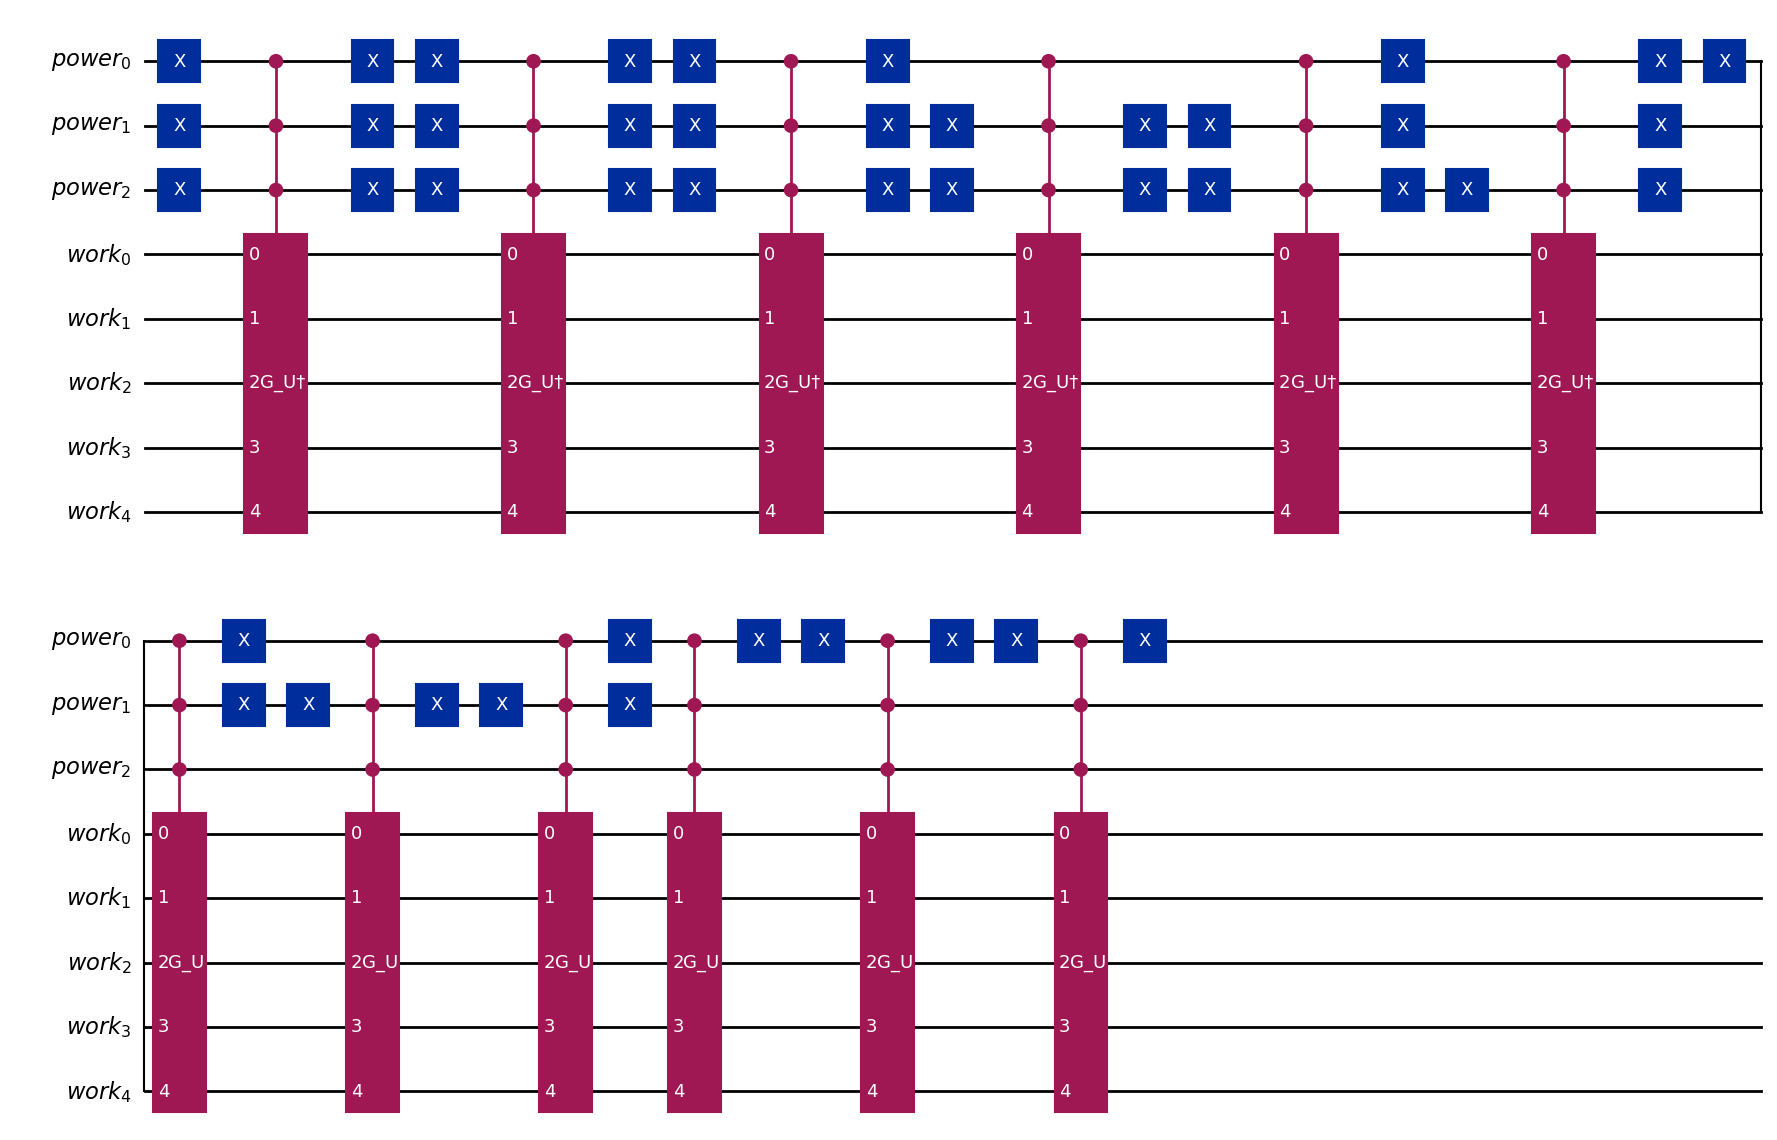

In [49]:
# Build SELECT_G over powers of G_U

M = 3
power_labels = list(range(-M, M + 1))
num_power_states = len(power_labels)

n_power_qubits = math.ceil(math.log2(num_power_states))
power_dim = 2 ** n_power_qubits

print("M =", M)
print("power labels =", power_labels)
print("n_power_qubits =", n_power_qubits)
print("power_dim =", power_dim)


def control_on_power_state(qc, power, encoded_state):
    bitstring = format(encoded_state, f"0{len(power)}b")[::-1]

    for q, b in zip(power, bitstring):
        if b == "0":
            qc.x(q)


def undo_control_on_power_state(qc, power, encoded_state):
    bitstring = format(encoded_state, f"0{len(power)}b")[::-1]

    for q, b in zip(power, bitstring):
        if b == "0":
            qc.x(q)


def append_gate_controlled_on_power_state(qc, power, encoded_state, gate, targets):
    control_on_power_state(qc, power, encoded_state)

    controlled_gate = gate.control(len(power))
    qc.append(controlled_gate, list(power) + list(targets))

    undo_control_on_power_state(qc, power, encoded_state)


power = QuantumRegister(n_power_qubits, "power")
work = QuantumRegister(n_work_qubits, "work")

SELECT_G_qc = QuantumCircuit(power, work, name="SELECT_G")

for encoded_state, m in enumerate(power_labels):
    if m == 0:
        continue

    if m > 0:
        for _ in range(m):
            append_gate_controlled_on_power_state(
                SELECT_G_qc,
                power[:],
                encoded_state,
                G_U_gate,
                work[:],
            )

    if m < 0:
        for _ in range(abs(m)):
            append_gate_controlled_on_power_state(
                SELECT_G_qc,
                power[:],
                encoded_state,
                G_U_dagger_gate,
                work[:],
            )

SELECT_G_gate = SELECT_G_qc.to_gate()
SELECT_G_gate.name = "SELECT_G"

print("SELECT_G built.")
print("SELECT_G qubits =", SELECT_G_qc.num_qubits)
print("SELECT_G depth =", SELECT_G_qc.depth())
print("SELECT_G gate count =", SELECT_G_qc.count_ops())

SELECT_G_qc.draw("mpl")

#####Neeed to change the number of x gates used between the consecutive applications of same power. 

This circuit is the controlled-power selector used for the Fourier expansion. The three power-register qubits encode which integer power of the Grover operator should be applied to the five-qubit work register.

For each encoded value, the surrounding \(X\) gates temporarily convert that binary pattern into the all-one control condition. This allows the corresponding multi-controlled \(G_U\) or \(G_U^\dagger\) block to activate only for that specific power-register state.

Positive powers are implemented by repeating the controlled \(G_U\) block, while negative powers use repeated controlled \(G_U^\dagger\). The zero-power branch applies no operation, so it acts as the identity.

The circuit appears large because every possible power is handled as a separate controlled case, and higher powers require multiple repeated Grover blocks.

After the Grover reflection operator is constructed, its eigenstates satisfy

$$
G_U|\phi^{\pm}\rangle
=
e^{\pm i\phi}|\phi^{\pm}\rangle.
$$

Applying integer powers of the operator produces the Fourier harmonics

$$
G_U^m|\phi^{\pm}\rangle
=
e^{\pm im\phi}|\phi^{\pm}\rangle.
$$

The target phase function is approximated through a truncated Fourier expansion,

$$
e^{-i\tau\cos\phi}
\approx
\sum_{m=-M}^{M}\beta_m e^{im\phi}.
$$

Therefore, the operator form used in the circuit is

$$
\sum_{m=-M}^{M}\beta_m G_U^m
\approx
e^{-i\tau\cos\phi}.
$$

Here, \(m=0\) gives the identity, positive \(m\) gives powers of \(G_U\), and negative \(m\) gives powers of \(G_U^\dagger\).

In [ ]:
# Compute beta_m coefficients

# discrete fourier tranformation of the target function f(phi) = exp(-i tau cos(phi)) over phi in [0, 2pi)
################ need to undestand the sampling properly. 
t = 0.4
tau = alpha * t

print("t =", t)
print("tau = alpha * t =", tau)

num_samples = 8192

phi_grid = np.linspace(0, 2 * np.pi, num_samples, endpoint=False)

# Target function:
# f(phi) = exp(-i tau cos(phi))
target_values = np.exp(-1j * tau * np.cos(phi_grid))

beta = {}

for m in power_labels:
    beta_m = np.mean(target_values * np.exp(-1j * m * phi_grid))
    beta[m] = beta_m

lambda_beta = sum(abs(beta[m]) for m in power_labels)

print("beta coefficients:")
for m in power_labels:
    print(f"m={m:2d}: beta={beta[m]}, |beta|={abs(beta[m])}")

print("\nlambda_beta =", lambda_beta)

t = 0.4
tau = alpha * t = 0.8
beta coefficients:
m=-3: beta=(-4.163336342344337e-17+0.010246766330553658j), |beta|=0.010246766330553658
m=-2: beta=(-0.07581776248494476+2.7755575615628914e-17j), |beta|=0.07581776248494476
m=-1: beta=(-2.7755575615628914e-17-0.36884204609417j), |beta|=0.36884204609417
m= 0: beta=(0.8462873527504802+2.7755575615628914e-17j), |beta|=0.8462873527504802
m= 1: beta=(-4.163336342344337e-17-0.36884204609417004j), |beta|=0.36884204609417004
m= 2: beta=(-0.07581776248494476+1.3877787807814457e-17j), |beta|=0.07581776248494476
m= 3: beta=(-1.3877787807814457e-17+0.010246766330553658j), |beta|=0.010246766330553658

lambda_beta = 1.7561005025698169


This block computes the Fourier coefficients used to weight the different powers of the Grover operator. The target phase function is evaluated over a dense grid of phase values,

$$
f(\phi)=e^{-i\tau\cos\phi},
\qquad
\tau=\alpha t.
$$

Each coefficient is obtained from the corresponding Fourier component,

$$
\beta_m
\approx
\frac{1}{N}
\sum_{r=0}^{N-1}
f(\phi_r)e^{-im\phi_r}.
$$

Finally, the normalization constant

$$
\lambda_\beta
=
\sum_{m=-M}^{M}
|\beta_m|
$$

is computed for preparing the coefficient register in the later LCU circuit.

I shuold not select the beta coeffs randomly. 

In [51]:
# Build PREPARE_beta and PHASE_beta

beta_amp_vec = np.zeros(power_dim, dtype=complex)
phase_diag = np.ones(power_dim, dtype=complex)

for encoded_state, m in enumerate(power_labels):
    beta_m = beta[m]

    beta_amp_vec[encoded_state] = np.sqrt(abs(beta_m) / lambda_beta)

    if abs(beta_m) > 1e-14:
        phase_diag[encoded_state] = beta_m / abs(beta_m)
    else:
        phase_diag[encoded_state] = 1.0

print("Norm of beta amplitude vector =", np.linalg.norm(beta_amp_vec))

PREPARE_beta = StatePreparation(beta_amp_vec)
PREPARE_beta.name = "PREPARE_beta"

PREPARE_beta_DAGGER = PREPARE_beta.inverse()
PREPARE_beta_DAGGER.name = "PREPARE_beta†"


PHASE_beta_qc = QuantumCircuit(n_power_qubits, name="PHASE_beta")
PHASE_beta_qc.unitary(np.diag(phase_diag), range(n_power_qubits), label="PHASE_beta")

PHASE_beta_gate = PHASE_beta_qc.to_gate()
PHASE_beta_gate.name = "PHASE_beta"

print("PREPARE_beta and PHASE_beta built.")

Norm of beta amplitude vector = 1.0
PREPARE_beta and PHASE_beta built.


This block computes the Fourier coefficients used to weight the different powers of the Grover operator. The target phase function is evaluated over a dense grid of phase values,

$$
f(\phi)=e^{-i\tau\cos\phi},
\qquad
\tau=\alpha t.
$$

Each coefficient is obtained from the corresponding Fourier component,

$$
\beta_m
\approx
\frac{1}{N}
\sum_{r=0}^{N-1}
f(\phi_r)e^{-im\phi_r}.
$$

Finally, the normalization constant

$$
\lambda_\beta
=
\sum_{m=-M}^{M}
|\beta_m|
$$

is computed for preparing the coefficient register in the later LCU circuit.

LCU phase block built.
LCU phase block qubits = 8
LCU phase block depth = 4
LCU phase block gate count = OrderedDict([('PREPARE_beta', 1), ('PHASE_beta', 1), ('SELECT_G', 1), ('PREPARE_beta†', 1)])


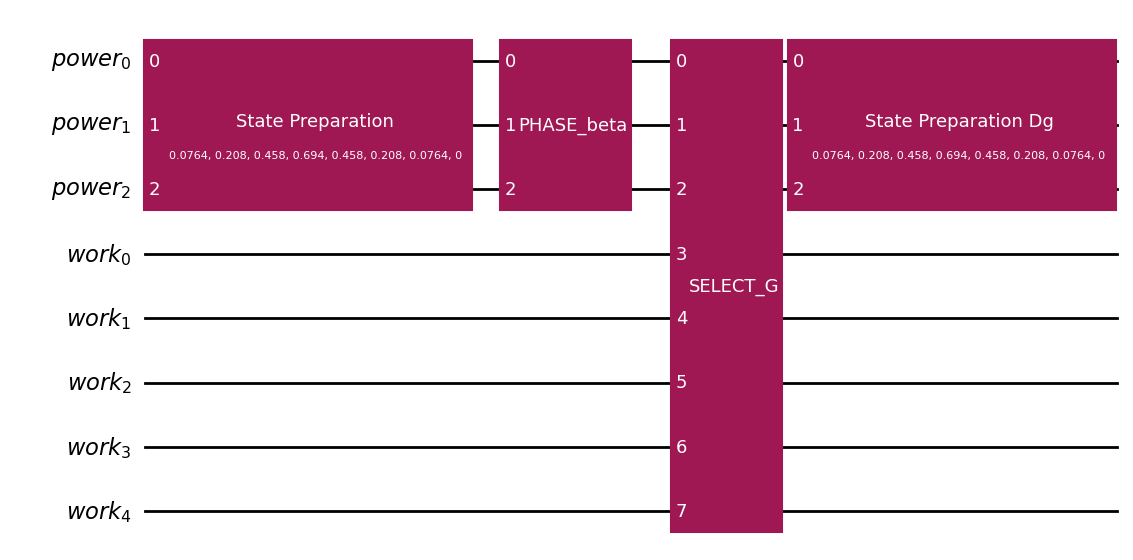

In [ ]:
# Build LCU phase block

power = QuantumRegister(n_power_qubits, "power")
work = QuantumRegister(n_work_qubits, "work")

LCU_phase_qc = QuantumCircuit(power, work, name="LCU_phase_block")

LCU_phase_qc.append(PREPARE_beta, power[:])
LCU_phase_qc.append(PHASE_beta_gate, power[:])
LCU_phase_qc.append(SELECT_G_gate, power[:] + work[:])
LCU_phase_qc.append(PREPARE_beta_DAGGER, power[:])

LCU_phase_gate = LCU_phase_qc.to_gate()
LCU_phase_gate.name = "LCU_phase_block"

print("LCU phase block built.")
print("LCU phase block qubits =", LCU_phase_qc.num_qubits)
print("LCU phase block depth =", LCU_phase_qc.depth())
print("LCU phase block gate count =", LCU_phase_qc.count_ops())

LCU_phase_qc.draw("mpl")



############ change the phase_beta should be next to select. as it ensure unitary powers are selected first and then the phase is applied.

The LCU block combines the different powers of the Grover operator into one coherent circuit. First, `PREPARE_beta` creates a superposition over the power labels using the magnitudes of the Fourier coefficients. `PHASE_beta` then adds the complex phase associated with each coefficient.

Next, `SELECT_G` applies the corresponding power of G_U to the work register for every power label in superposition. Finally, `PREPARE_beta^dagger` uncomputes the power register.

When the power register returns to |0>, the work register has effectively undergone the normalized linear combination of Grover powers required to approximate the target phase evolution.

In [21]:
# # Verification 4: LCU top-left block

# U_LCU = Operator(LCU_phase_qc).data
# G = Operator(G_U_qc).data

# dim_power = 2 ** n_power_qubits
# dim_work = 2 ** n_work_qubits

# # Extract block where power register starts and ends in |0...0>.
# # Since power register comes first, power bits are lower-order bits.
# # Full basis index = power_value + dim_power * work_value.

# lcu_block = np.zeros((dim_work, dim_work), dtype=complex)

# for work_row in range(dim_work):
#     for work_col in range(dim_work):
#         full_row = 0 + dim_power * work_row
#         full_col = 0 + dim_power * work_col

#         lcu_block[work_row, work_col] = U_LCU[full_row, full_col]


# expected_poly = np.zeros_like(G, dtype=complex)

# for m in power_labels:
#     if m == 0:
#         G_power = np.eye(dim_work, dtype=complex)

#     elif m > 0:
#         G_power = np.linalg.matrix_power(G, m)

#     else:
#         G_power = np.linalg.matrix_power(G.conj().T, abs(m))

#     expected_poly += beta[m] * G_power

# expected_poly = expected_poly / lambda_beta

# err_lcu = np.linalg.norm(lcu_block - expected_poly)

# print("Verification 4: LCU top-left block")
# print("|| extracted block - expected polynomial || =", err_lcu)

# unitarity_error = np.linalg.norm(lcu_block.conj().T @ lcu_block - np.eye(dim_work))

# print("Top-left block unitarity error =", unitarity_error)
# print("Note: nonzero unitarity error is expected before OAA/amplification.")

In [ ]:
# # Verification 4: Lightweight LCU polynomial check
# # This avoids Operator(LCU_phase_qc).data
# # It verifies the intended polynomial:
# # P(G_U) = (1/lambda_beta) sum_m beta_m G_U^m
# # This is the top-left block that the LCU circuit is designed to encode.

# G = Operator(G_U_qc).data
# expected_poly = np.zeros_like(G, dtype=complex)

# for m in power_labels:
#     if m == 0:
#         G_power = np.eye(G.shape[0], dtype=complex)

#     elif m > 0:
#         G_power = np.linalg.matrix_power(G, m)

#     else:
#         G_power = np.linalg.matrix_power(G.conj().T, abs(m))

#     expected_poly += beta[m] * G_power

# expected_poly = expected_poly / lambda_beta

# print("Verification 4: Lightweight LCU polynomial check")
# print("Polynomial matrix shape:", expected_poly.shape)

# poly_unitarity_error = np.linalg.norm(
#     expected_poly.conj().T @ expected_poly - np.eye(expected_poly.shape[0])
# )

# print("Polynomial unitarity error =", poly_unitarity_error)
# print("Note: nonzero error is expected before OAA/amplification.")

Verification 4: Lightweight LCU polynomial check
Polynomial matrix shape: (32, 32)
Polynomial unitarity error = 3.8283302317732004
Note: nonzero error is expected before OAA/amplification.


##testing LCU

In [ ]:
# Dimensions
n_work_qubits = G_U_qc.num_qubits
dim_work = 2 ** n_work_qubits

n_power_qubits = LCU_phase_qc.num_qubits - n_work_qubits
dim_power = 2 ** n_power_qubits

print("dim_work =", dim_work)
print("dim_power =", dim_power)

dim_work = 32
dim_power = 8


In [56]:
from qiskit.quantum_info import Statevector
import numpy as np

dim_total = dim_power * dim_work

def apply_lcu_success_block(work_state):
    """
    Applies LCU_phase_qc to |0>_power ⊗ |work_state>,
    then extracts the power-register-|0> component.
    """

    work_state = np.asarray(work_state, dtype=complex)
    work_state = work_state / np.linalg.norm(work_state)

    initial_state = np.zeros(dim_total, dtype=complex)

    # Qubit ordering:
    # full_index = power_index + dim_power * work_index
    for work_index, amplitude in enumerate(work_state):
        full_index = dim_power * work_index
        initial_state[full_index] = amplitude

    final_state = Statevector(initial_state).evolve(LCU_phase_qc).data

    success_state = np.zeros(dim_work, dtype=complex)

    for work_index in range(dim_work):
        full_index = dim_power * work_index
        success_state[work_index] = final_state[full_index]

    return success_state

In [59]:
dim_work = 2 ** n_work_qubits
dim_power = 2 ** n_power_qubits

G_U_mat = Operator(G_U_qc).data
G_U_dagger_mat = G_U_mat.conj().T

B_expected = np.zeros(
    (dim_work, dim_work),
    dtype=complex
)

for m in power_labels:
    if m == 0:
        G_power = np.eye(dim_work, dtype=complex)

    elif m > 0:
        G_power = np.linalg.matrix_power(G_U_mat, m)

    else:
        G_power = np.linalg.matrix_power(
            G_U_dagger_mat,
            abs(m)
        )

    B_expected += beta[m] * G_power

B_expected /= lambda_beta

print("B_expected constructed.")
print("B_expected shape =", B_expected.shape)

B_expected constructed.
B_expected shape = (32, 32)


In [60]:
rng = np.random.default_rng(7)

number_of_tests = 5
errors = []

for test_number in range(number_of_tests):

    work_state = (
        rng.normal(size=dim_work)
        + 1j * rng.normal(size=dim_work)
    )
    work_state /= np.linalg.norm(work_state)

    circuit_output = apply_lcu_success_block(work_state)
    expected_output = B_expected @ work_state

    error = np.linalg.norm(circuit_output - expected_output)
    errors.append(error)

    print(
        f"Test {test_number}: "
        f"success-block error = {error:.3e}"
    )

print("Maximum error =", max(errors))

Test 0: success-block error = 1.984e-11
Test 1: success-block error = 1.958e-11
Test 2: success-block error = 2.021e-11
Test 3: success-block error = 1.986e-11
Test 4: success-block error = 2.003e-11
Maximum error = 2.0207901345435216e-11


In [ ]:
# summary until now

print("=" * 80)
print("PIPELINE SUMMARY")
print("=" * 80)

print("\nProblem Hamiltonian:")
print("H = 0.7 XX - 0.5 ZY + 0.8 YZ")
print("alpha =", alpha)

print("\nBuilt blocks:")
print("1. PREPARE_G")
print("2. Problem-specific SELECT")
print("3. Probability oracle U_p")
print("4. Reflections R_good and R_zero")
print("5. Grover/reflection operator G_U")
print("6. SELECT_G over powers of G_U")
print("7. LCU phase block")

print("\nVerification checkpoints:")
print("1. SELECT block encoding: <G|SELECT|G> = H/alpha")
print("2. Probability oracle: P(anc=1) = 1/2 - 1/2 <H/alpha>")
print("3. Grover phase signal: p = sin^2(theta), phases related to ±2theta")
print("4. LCU block: top-left block equals normalized polynomial in G_U")

print("\nImportant:")
print("This does NOT use direct Pauli evolution e^{-it c_j P_j}.")
print("Pauli strings are used only inside SELECT.")
print("The phase block is an LCU block before OAA/amplification.")

PIPELINE SUMMARY

Problem Hamiltonian:
H = 0.7 XX - 0.5 ZY + 0.8 YZ
alpha = 2.0

Built blocks:
1. PREPARE_G
2. Problem-specific SELECT
3. Probability oracle U_p
4. Reflections R_good and R_zero
5. Grover/reflection operator G_U
6. SELECT_G over powers of G_U
7. LCU phase block

Verification checkpoints:
1. SELECT block encoding: <G|SELECT|G> = H/alpha
2. Probability oracle: P(anc=1) = 1/2 - 1/2 <H/alpha>
3. Grover phase signal: p = sin^2(theta), phases related to ±2theta
4. LCU block: top-left block equals normalized polynomial in G_U

Important:
This does NOT use direct Pauli evolution e^{-it c_j P_j}.
Pauli strings are used only inside SELECT.
The phase block is an LCU block before OAA/amplification.


In [ ]:
# Block 19: Extract LCU success block B
# A = LCU_phase_block
# B = <0_power| A |0_power>
# This B is the actual block encoded by the LCU circuit.
# It should equal to B = (1/lambda_beta) sum_m beta_m G_U^m

A_mat = Operator(LCU_phase_qc).data
dim_power = 2 ** n_power_qubits
dim_work = 2 ** n_work_qubits

B_lcu = np.zeros((dim_work, dim_work), dtype=complex)

# Qiskit ordering:
# full index = power_value + dim_power * work_value
# We extract power_value = 0 block.

for work_row in range(dim_work):
    for work_col in range(dim_work):
        full_row = 0 + dim_power * work_row
        full_col = 0 + dim_power * work_col
        B_lcu[work_row, work_col] = A_mat[full_row, full_col]

print("Extracted LCU success block B.")
print("B_lcu shape =", B_lcu.shape)

# Compare with expected polynomial
G = Operator(G_U_qc).data

expected_poly = np.zeros_like(G, dtype=complex)

for m in power_labels:
    if m == 0:
        G_power = np.eye(dim_work, dtype=complex)
    elif m > 0:
        G_power = np.linalg.matrix_power(G, m)
    else:
        G_power = np.linalg.matrix_power(G.conj().T, abs(m))

    expected_poly += beta[m] * G_power

expected_poly = expected_poly / lambda_beta
block_error = np.linalg.norm(B_lcu - expected_poly)

print("|| B_lcu - expected_poly || =", block_error)

Extracted LCU success block B.
B_lcu shape = (32, 32)
|| B_lcu - expected_poly || = 1.1639007616636813e-10


In [ ]:
# Block 20: Build reflection about power-register zero

def build_R_power_zero_gate(n_power_qubits, n_work_qubits):
    total_qubits = n_power_qubits + n_work_qubits

    qc = QuantumCircuit(total_qubits, name="R_power_zero")

    power_qubits = list(range(n_power_qubits))

    # Convert |0...0> on power register to |1...1>
    qc.x(power_qubits)

    # Apply -1 phase on |1...1> of the power register
    if n_power_qubits == 1:
        qc.z(power_qubits[0])
    else:
        qc.h(power_qubits[-1])
        qc.mcx(power_qubits[:-1], power_qubits[-1])
        qc.h(power_qubits[-1])

    # Undo masking
    qc.x(power_qubits)

    return qc.to_gate()

R_power_zero_gate = build_R_power_zero_gate(n_power_qubits, n_work_qubits)

print("R_power_zero built.")
print("Acts on total qubits =", n_power_qubits + n_work_qubits)

R_power_zero built.
Acts on total qubits = 8


In [25]:
# Block 21: Build one-step OAA-amplified LCU block

power = QuantumRegister(n_power_qubits, "power")
work = QuantumRegister(n_work_qubits, "work")

OAA_1_qc = QuantumCircuit(power, work, name="OAA_1_LCU_phase")

A_gate = LCU_phase_gate
A_dagger_gate = A_gate.inverse()
A_dagger_gate.name = "LCU_phase†"

OAA_1_qc.append(A_gate, power[:] + work[:])
OAA_1_qc.append(R_power_zero_gate, power[:] + work[:])
OAA_1_qc.append(A_dagger_gate, power[:] + work[:])
OAA_1_qc.append(R_power_zero_gate, power[:] + work[:])
OAA_1_qc.append(A_gate, power[:] + work[:])

OAA_1_gate = OAA_1_qc.to_gate()
OAA_1_gate.name = "OAA_1_LCU_phase"

print("One-step OAA circuit built.")
print("OAA circuit qubits =", OAA_1_qc.num_qubits)
print("OAA circuit depth =", OAA_1_qc.depth())
print("OAA circuit gate count =", OAA_1_qc.count_ops())

One-step OAA circuit built.
OAA circuit qubits = 8
OAA circuit depth = 5
OAA circuit gate count = OrderedDict([('LCU_phase_block', 2), ('R_power_zero', 2), ('LCU_phase†', 1)])


In [26]:
# Block 22: Extract OAA-amplified success block

OAA_mat = Operator(OAA_1_qc).data

B_oaa = np.zeros((dim_work, dim_work), dtype=complex)

for work_row in range(dim_work):
    for work_col in range(dim_work):
        full_row = 0 + dim_power * work_row
        full_col = 0 + dim_power * work_col
        B_oaa[work_row, work_col] = OAA_mat[full_row, full_col]

print("Extracted OAA success block B_oaa.")
print("B_oaa shape =", B_oaa.shape)

Extracted OAA success block B_oaa.
B_oaa shape = (32, 32)


In [ ]:
# Block 23: Verify OAA block transformation
#B_oaa_theory = 3 * B_lcu - 4 * B_lcu @ B_lcu.conj().T @ B_lcu

#oaa_formula_error = np.linalg.norm(B_oaa - B_oaa_theory)

#print("OAA formula verification")
#print("|| B_oaa - (3B - 4BB†B) || =", oaa_formula_error)

OAA formula verification
|| B_oaa - (3B - 4BB†B) || = 10.980127500964116


In [27]:
# Corrected Block 23: Verify OAA block transformation
# Depending on reflection convention, the OAA block may be:
# B_oaa ≈  3B - 4BB†B
# or
# B_oaa ≈ -(3B - 4BB†B)
# The minus is only a global phase convention.

B_oaa_theory = 3 * B_lcu - 4 * B_lcu @ B_lcu.conj().T @ B_lcu

err_plus = np.linalg.norm(B_oaa - B_oaa_theory)
err_minus = np.linalg.norm(B_oaa + B_oaa_theory)

print("OAA formula verification with global-sign check")
print("|| B_oaa - (3B - 4BB†B) ||  =", err_plus)
print("|| B_oaa + (3B - 4BB†B) ||  =", err_minus)

if err_minus < err_plus:
    print("\nResult:")
    print("B_oaa ≈ -(3B - 4BB†B)")
    print("This is correct up to a global minus sign.")
else:
    print("\nResult:")
    print("B_oaa ≈ +(3B - 4BB†B)")

OAA formula verification with global-sign check
|| B_oaa - (3B - 4BB†B) ||  = 10.980220631221357
|| B_oaa + (3B - 4BB†B) ||  = 6.960928209638715e-10

Result:
B_oaa ≈ -(3B - 4BB†B)
This is correct up to a global minus sign.


In [28]:
# Block 24: Check singular values before and after OAA

sv_lcu = np.linalg.svd(B_lcu, compute_uv=False)
sv_oaa = np.linalg.svd(B_oaa, compute_uv=False)

expected_lcu_scale = 1 / lambda_beta
expected_oaa_scale = 3 / lambda_beta - 4 / (lambda_beta ** 3)

print("lambda_beta =", lambda_beta)

print("\nExpected LCU scale ~ 1/lambda_beta:")
print(expected_lcu_scale)

print("Expected one-step OAA scale ~ 3/lambda - 4/lambda^3:")
print(expected_oaa_scale)

print("\nSingular values of B_lcu:")
print(sv_lcu)

print("\nSingular values of B_oaa:")
print(sv_oaa)

print("\nMean singular value before OAA:", np.mean(sv_lcu))
print("Mean singular value after OAA:", np.mean(sv_oaa))

lambda_beta = 1.756100502569817

Expected LCU scale ~ 1/lambda_beta:
0.5694434905841861
Expected one-step OAA scale ~ 3/lambda - 4/lambda^3:
0.969726072985671

Singular values of B_lcu:
[0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561
 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561
 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561
 0.568561 0.568561 0.568561 0.568561 0.568561 0.568561 0.568261 0.568261]

Singular values of B_oaa:
[0.970771 0.970771 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507
 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507
 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507
 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507 0.970507]

Mean singular value before OAA: 0.5685423756067207
Mean singular value after OAA: 0.9705235562495853


In [ ]:
# Block 25: Check polynomial action on eigenphases of G_U

eigvals, eigvecs = np.linalg.eig(G)

phases = np.angle(eigvals)

# Polynomial value from beta coefficients
def poly_value(phi):
    val = 0.0 + 0.0j
    for m in power_labels:
        val += beta[m] * np.exp(1j * m * phi)
    return val / lambda_beta

poly_errors = []

for k in range(len(eigvals)):
    v = eigvecs[:, k]
    v = v / np.linalg.norm(v)

    actual = B_lcu @ v
    expected = poly_value(phases[k]) * v

    err = np.linalg.norm(actual - expected)
    poly_errors.append(err)

print("Polynomial eigenphase check")
print("max error over eigenvectors =", np.max(poly_errors))
print("mean error over eigenvectors =", np.mean(poly_errors))

Polynomial eigenphase check
max error over eigenvectors = 2.0875155006589768e-11
mean error over eigenvectors = 2.05753055701596e-11


In [30]:
# Block 26: Final status after OAA diagnostic

print("=" * 90)
print("FINAL STATUS")
print("=" * 90)

print("\nWe built:")
print("1. Problem-specific SELECT")
print("2. PREPARE_G")
print("3. Probability oracle U_p")
print("4. Grover/reflection operator G_U")
print("5. LCU block A_LCU")
print("6. One-step OAA-amplified block A_OAA")

print("\nMathematical object before OAA:")
print("B_lcu = <0_power| A_LCU |0_power>")
print("      = (1/lambda_beta) sum_m beta_m G_U^m")

print("\nMathematical object after one OAA step:")
print("B_oaa ≈ 3B_lcu - 4B_lcu B_lcu† B_lcu")

print("\nImportant:")
print("This is an amplified block-encoded phase oracle.")
print("It is not guaranteed to be exactly deterministic unless the success-amplitude condition is satisfied.")

print("\nUse as final current research artifact:")
print("LCU + OAA amplified block-encoded phase oracle.")

FINAL STATUS

We built:
1. Problem-specific SELECT
2. PREPARE_G
3. Probability oracle U_p
4. Grover/reflection operator G_U
5. LCU block A_LCU
6. One-step OAA-amplified block A_OAA

Mathematical object before OAA:
B_lcu = <0_power| A_LCU |0_power>
      = (1/lambda_beta) sum_m beta_m G_U^m

Mathematical object after one OAA step:
B_oaa ≈ 3B_lcu - 4B_lcu B_lcu† B_lcu

Important:
This is an amplified block-encoded phase oracle.
It is not guaranteed to be exactly deterministic unless the success-amplitude condition is satisfied.

Use as final current research artifact:
LCU + OAA amplified block-encoded phase oracle.
